In [204]:
#import os
#print("Current directory:", os.getcwd())
#print("\nFiles in this directory:")
#for file in os.listdir():
#    print(f"  - {file}")

In [205]:
# =========================
# =========================

# 1. Exploratory Data Analysis

# =========================
# =========================


In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:Desktop/International_Finance_Project/merged_data_quant_trading_model.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.set_index('date', inplace=True)

In [207]:
#1 EM Index Returns
df["em_return"] = np.log(df["emb_price"] / df["emb_price"].shift(1))
#2. Oil returns
df["oil_return"] = np.log(df["oil_price"] / df["oil_price"].shift(1))
#3. VIX change
df["delta_vix"] = np.log(df['vix']).diff() * 100
#4. Credit spread change
df["delta_credit_spread"] = df["credit_spread"].diff()

In [208]:
#df["target"] = df["em_return"].shift(-1)
#clean data by removing null values w/ dropna
df = df.dropna()

In [209]:
# =========================
# 1. DEFINE VIX SPIKE EVENTS
# =========================
threshold = df['delta_vix'].quantile(0.80)  # top 20% moves

raw_spike_dates = df[df['delta_vix'] > threshold].index

# Optional but IMPORTANT: de-cluster events (avoid overlapping shocks)
min_gap = 20  # days between events
spike_dates = []

last_date = None
for d in raw_spike_dates:
    if last_date is None or (d - last_date).days > min_gap:
        spike_dates.append(d)
        last_date = d

delta_vix_array = df.loc[df.index.isin(spike_dates), 'delta_vix'].values

In [210]:
len(delta_vix_array)

140

In [211]:
# =========================
# 3. BUILD EVENT WINDOWS
# =========================
window = 240
responses = []

for date in spike_dates:
    future_prices = df.loc[date:].iloc[:window]['emb_price']
    
    if len(future_prices) == window:
        base = future_prices.iloc[0]
        
        # THIS is what you want
        normalized = future_prices / base   # starts at 1.0
        
        responses.append(normalized.values)

responses = np.array(responses)

In [212]:
# =========================
# 4. AVERAGE RESPONSE
# =========================

avg_path = responses.mean(axis=0)

#avg_price_shock_window = []

#For element in responses:
#    avg_price_shock_window.append(np.mean(element))

#avg_price_shock_window = np.round(avg_price_shock_window, 4)

In [213]:
# =========================
# 5. FIND KEY LAGS
# =========================

# Trough (lowest point)
trough_lag = np.argmin(avg_path)
trough_value = avg_path[trough_lag]

#Recovery from Trough Value
target = trough_value + 0.8 * (1.0 - trough_value)

recovery_80_idx = np.where(avg_path[trough_lag:] >= target)[0]
recovery_80_lag = recovery_80_idx[0] + 1 if len(recovery_80_idx) > 0 else np.nan

In [214]:
# =========================
# 6. Event-Level LAGS
# =========================


#Idea: Find the correlation between selected VIX values and price values in each window after each trough
min_drawdown_threshold = 0.95 # ~ 5% drawdown minimum

trough_times = []
recovery_times = []
acceptable_df_responses = []
delta_vix_array_with_threshold = []

count = 0 

for r in responses:
    t_trough = np.argmin(r)
    trough_val = r[t_trough]

    # Skip weak selloffs
    if trough_val > min_drawdown_threshold:
        continue

    delta_vix_array_with_threshold.append(delta_vix_array[count])
    
    acceptable_df_responses.append(r)
    
    target = trough_val + 0.8 * (1.0 - trough_val)

    # ONLY search AFTER trough
    rec_idx = np.where(r[t_trough:] >= target)[0]

    if len(rec_idx) > 0:
        t_recovery = t_trough + rec_idx[0]
    else:
        t_recovery = np.nan

    trough_times.append(t_trough)
    recovery_times.append(t_recovery)

    count += 1
    
trough_times = np.array(trough_times)
recovery_times = np.array(recovery_times)

In [215]:
trough_times

array([ 81,  63,  46,  26,  11, 230, 239, 225, 210, 233, 233, 217, 238,
       229, 210, 195, 179, 163, 136,  97, 227, 206, 184, 169, 152, 137,
       123,  94,  74,  55,  40,  21,   5, 143, 126,  73,  59, 227, 213,
       233, 237, 223, 238, 237, 238, 239, 228, 214, 199, 230, 229, 215,
       199, 179, 163, 140, 126, 107,  92,  72,  57,  42,  27, 219, 200,
       182, 167, 151, 123, 108,  90,  74,  59,  44,  24, 152, 131,  81])

In [216]:
# =========================
# 6.5. Constructing A Data Frame for our Linear Regression
# =========================

return_after_trough = []

count = 0

for element in acceptable_df_responses:
    return_after_trough.append(np.log(np.mean(element[trough_times[count]:])/element[int(trough_times[count])]) * 100)
    count += 1

df_reg = pd.DataFrame({
    "Return After Trough (%)": return_after_trough,
    "Delta Vix": delta_vix_array_with_threshold
})

In [217]:
# To explain this dataframe, I'm just taking the return made in each 240-day window if you bought at the trough and held till the peak
# Then I'm also including all of the VIX spikes that kicked off each period

In [225]:
# =========================
# 7. Distributions (Median + Standard Deviation)
# =========================

median_trough = np.nanmedian(trough_times)
std_trough = np.nanstd(trough_times)

# Recovery stats
median_recovery = np.nanmedian(recovery_times)
std_recovery = np.nanstd(recovery_times)

print(f"Median trough lag: {median_trough:.1f} days")
print(f"Std trough lag: {std_trough:.1f}")

print("\n")

print(f"Median recovery lag: {median_recovery:.1f} days")
print(f"Std recovery lag: {std_recovery:.1f}")

print("\n")

time_to_recovery = recovery_times - trough_times

median_ttr = np.nanmedian(time_to_recovery)
std_ttr = np.nanstd(time_to_recovery)

print(f"\nMedian time from trough to recovery: {median_ttr:.1f} days")
print(f"Std time from trough to recovery: {std_ttr:.1f}")

Median trough lag: 157.5 days
Std trough lag: 73.3


Median recovery lag: 135.0 days
Std recovery lag: 54.9



Median time from trough to recovery: 41.0 days
Std time from trough to recovery: 29.6


In [226]:
print(np.sum(~np.isnan(recovery_times)), "recoveries out of", len(recovery_times), "occur meaningfully")

42 recoveries out of 78 occur meaningfully


In [227]:
violations = np.sum((recovery_times < trough_times) & ~np.isnan(recovery_times))
print("Violations:", violations)

Violations: 0


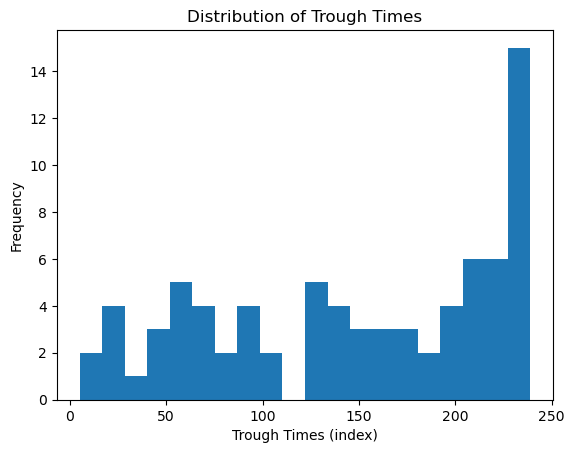

In [228]:
import matplotlib.pyplot as plt

plt.hist(trough_times, bins=20)
plt.xlabel("Trough Times (index)")
plt.ylabel("Frequency")
plt.title("Distribution of Trough Times")
plt.show()

In [259]:
trough_times_below_median = trough_times[trough_times < 150]

In [338]:
print(np.median(trough_times_below_median))
print(np.std(trough_times_below_median))

74.0
39.90090928448116


In [318]:
mask = trough_times < np.median(trough_times)

recovery_times_trough_below_median = recovery_times[mask]

recovery_times_trough_below_median - trough_times[mask]

recovery_times_trough_below_median = recovery_times_trough_below_median[~np.isnan(recovery_times_trough_below_median)]

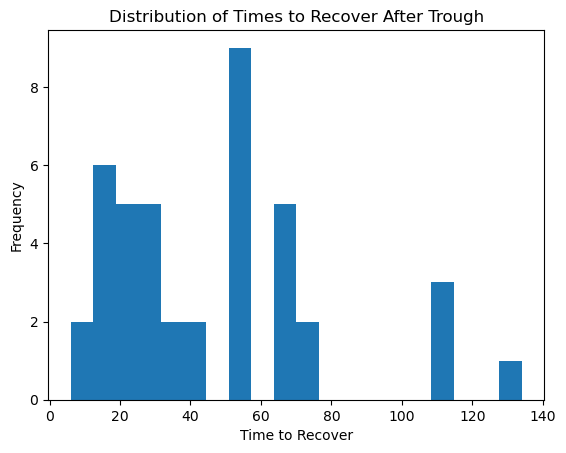

In [232]:
import matplotlib.pyplot as plt

plt.hist(recovery_times - trough_times, bins=20)
plt.xlabel("Time to Recover")
plt.ylabel("Frequency")
plt.title("Distribution of Times to Recover After Trough")
plt.show()

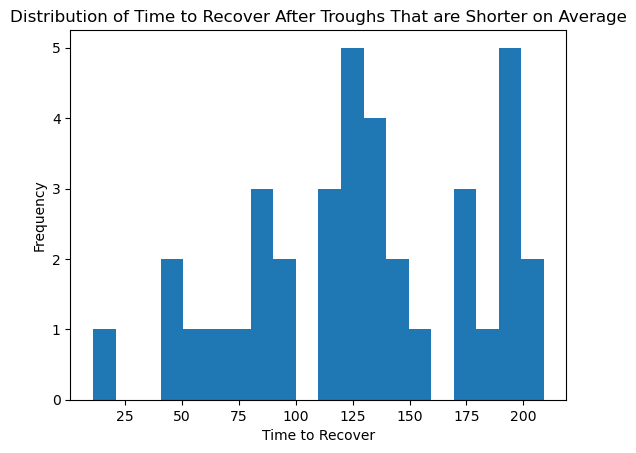

In [324]:
import matplotlib.pyplot as plt

plt.hist(recovery_times_trough_below_median, bins=20)
plt.xlabel("Time to Recover")
plt.ylabel("Frequency")
plt.title("Distribution of Time to Recover After Troughs That are Shorter on Average")
plt.show()

In [337]:
print(np.median(recovery_times_trough_below_median))
print(np.std(recovery_times_trough_below_median))

128.0
50.267669214894255


In [233]:
#Explanation of results:
# 1) The median recovery lag is less than the median trough lag because in a lot of cases, especially with sellofs that happen later in the cycle
#    recoveries just don't happen
# 2) The median difference between measured recovery times and trough times does show that when recoveries do happen, they tend to happen faster after 
#    the bottom-out of the sell-off

# 3) The distributions confirm this with a bimodal trough time distribution (the second cluster is skewed left with a lot of values 
#    clustered towards the right)
#    The Distribution of time to recover seems a lot more normally distributed

In [186]:
#4 cases
# Top 20% of VIX spikes and drawdown levels at minimum: 0.997 : 64/116 do recover  meaningfully
# Top 20% of VIX spikes and drawdown levels at minimum: 0.95 : 15/52 or 29% of drawdowns recover meaningfully-- This is a much less promising result
# If we increase our VIX threshold to the top 10% from 20%, our results with a drawdown minimum of 0.997:
#                42/80 or >50% of our samples are successfuly, up from earlier
# We decided to reject the top 30% of VIX spikes because it didn't significantly increase the number of windows to look at and it didn't improve our standard deviations from enough to justify making our signal a lot noiser

# We're sticking with the top 20% of VIX spikes to reduce Type I error

#For fun's sake, let's increase the number of days in our window to maybe account for the fact that larger drawdowns may take longer to recover 
#   We're also doing this because a minimum drawdown of 99% is not profitable

# Our new drawdown is at 5% 

# With a VIX threshold at the top 10%: We saw successes of 28/55 or 50%
# With a VIX threshold at the top 20%: We saw 42/78 or 54% of cases succeed

# We rejected increasing our drawdown minimum to > 5% because it increases our probability of getting a type I error, or our proportion of failures

In [187]:
# Mask for events that actually recovered
valid = ~np.isnan(recovery_times)

# Conditional stats
median_trough_cond = np.median(trough_times[valid])
std_trough_cond = np.std(trough_times[valid])

median_recovery_cond = np.median(recovery_times[valid])
std_recovery_cond = np.std(recovery_times[valid])

print("=== Conditional on Recovery ===")
print(f"Median trough lag: {median_trough_cond:.1f}")
print(f"Std trough lag: {std_trough_cond:.1f}")

print(f"Median recovery lag: {median_recovery_cond:.1f}")
print(f"Std recovery lag: {std_recovery_cond:.1f}")

=== Conditional on Recovery ===
Median trough lag: 85.5
Std trough lag: 51.5
Median recovery lag: 135.0
Std recovery lag: 54.9


In [188]:
time_to_recovery_cond = recovery_times[valid] - trough_times[valid]

median_ttr_cond = np.median(time_to_recovery_cond)
std_ttr_cond = np.std(time_to_recovery_cond)

print(f"\nMedian conditional time from trough to recovery: {median_ttr_cond:.1f} days")
print(f"Std conditional time from trough to recovery: {std_ttr_cond:.1f}")


Median conditional time from trough to recovery: 41.0 days
Std conditional time from trough to recovery: 29.6


In [189]:
#Explanation of new results, now we're examining only the events where a meaningful recovery happens
#I care significantly more about the fact that the median time until we have a trough is 85 days with a standard deviation of 51
#I care also significantly that the median time from trough to recover is 41 days with an std of 30 days
#However, key questions remain: why are the standard deviations so high
#And how do I predict which VIX spikes will cause a meaningful resurgence?

In [190]:
# =========================
# =========================

# 2. OLS Regression, Key Graphs and Results

# =========================
# =========================

In [191]:
from sklearn.model_selection import train_test_split

X = df_reg[["Delta Vix"]]   # predictor
y = df_reg["Return After Trough (%)"]  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [192]:
import statsmodels.api as sm

# add intercept
X_train_const = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Return After Trough (%)   R-squared:                       0.000
Model:                                 OLS   Adj. R-squared:                 -0.017
Method:                      Least Squares   F-statistic:                  0.003100
Date:                     Mon, 20 Apr 2026   Prob (F-statistic):              0.956
Time:                             20:36:51   Log-Likelihood:                -206.09
No. Observations:                       62   AIC:                             416.2
Df Residuals:                           60   BIC:                             420.4
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [193]:
X_test_const = sm.add_constant(X_test)

y_pred = model.predict(X_test_const)

In [194]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R^2 (test): {r2:.4f}")

RMSE: 5.9483
R^2 (test): -0.0147


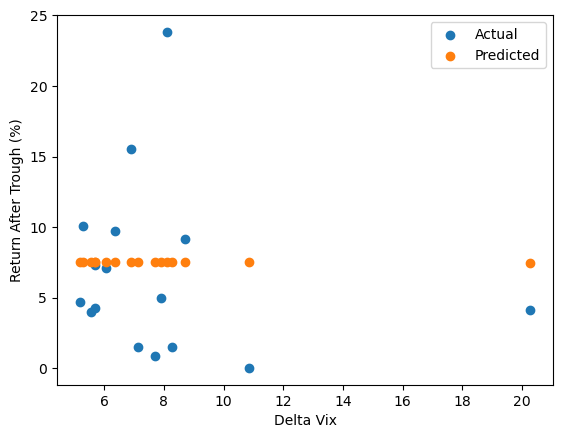

In [195]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("Delta Vix")
plt.ylabel("Return After Trough (%)")
plt.legend()
plt.show()

In [197]:
df_reg_sorted = df_reg.sort_values(by="Return After Trough (%)")
df_reg_sorted

,Return After Trough (%),Delta Vix
45,0.000000,6.079854
6,0.000000,33.567256
12,0.023907,10.842843
42,0.342429,13.725327
40,0.473720,18.987428
...,...,...
28,22.744971,12.631162
29,23.357120,12.352402
30,23.828108,8.110444
31,24.243368,7.540686


In [199]:
print(np.mean(df_reg_sorted["Return After Trough (%)"]))

np.float64(7.364668589305045)

In [200]:
print(np.std(df_reg_sorted["Return After Trough (%)"]))

6.567544026096797


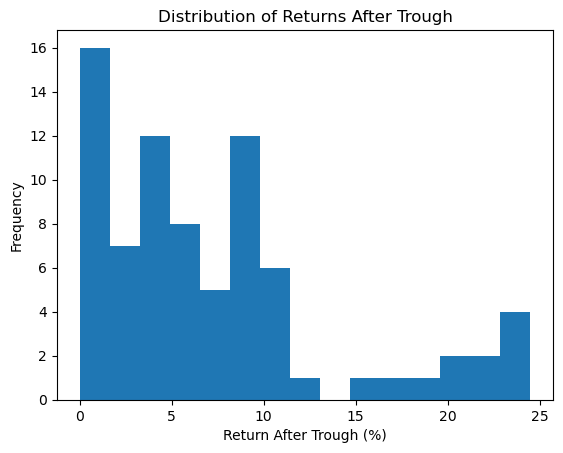

In [223]:
plt.hist(df_reg["Return After Trough (%)"], bins=15)
plt.xlabel("Return After Trough (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Returns After Trough")
plt.show()

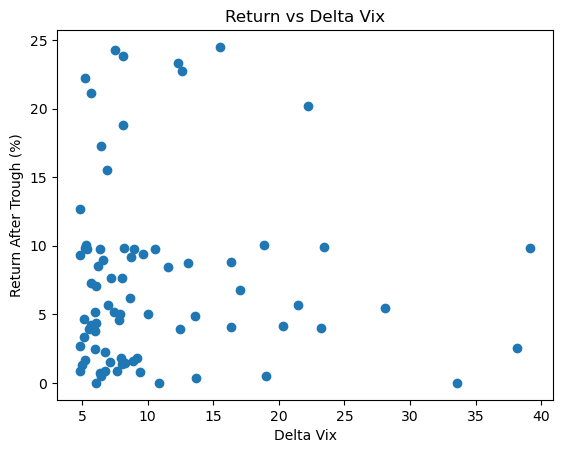

In [202]:
plt.scatter(
    df_reg["Delta Vix"],
    df_reg["Return After Trough (%)"]
)
plt.xlabel("Delta Vix")
plt.ylabel("Return After Trough (%)")
plt.title("Return vs Delta Vix")
plt.show()

In [ ]:
#From our results, we see that the magnitude of the shock isn't a good predictor for the magnitude of the returns 
# You'll make, even if you filter for only vix shocks that are significantly above average in impact

# What is significant is that when you do filter your trading strategy based on severity of VIX shock, all the returns you make if you buy at the trough
# Are on average 7.4% with a distribution that favors higher outliers (which is good)

# I think the VIX is a useful indicator since it represents shocks to the market which cause this trend but it's not the underlying causal factor I 
# Thought it was

In [ ]:
# =========================
# =========================

# 3. Simple Trading Rule and Backtest

# =========================
# =========================

In [335]:
# This trading model synthesizes our results and does something simple:
#      If there's a VIX spike that's so significant, it measures in the top 20% of VIX spikes, wait 74 days after the spike, since we want to trade 
#      early troughs and not later more unpredictable troughs. Also since the standard deviation of short-term trough times, let's put money in the 
#      position starting on day 24 and until day 114
#      Then wait approximately 130 days to exit out of the position
#       
#      Also, if we see that the ROC is not becoming less negative around the 74 day mark, wait another 25 days and test again
#      If that test is failed, wait another 25 days and test again
#      If after 50 days, it's not slowing down, don't execute since we're a standard deviation away from potential short-term trough times

In [363]:
list_of_returns = []
for element in acceptable_df_responses:
    if element[74] < 0.95:
        if not ((element[74]-element[64]) < (element[64]-element[54]) - 0.02):
            initial_element = element[74]
            end_element = element[202]

            my_return = (end_element/initial_element - 1) * 100
            list_of_returns.append(my_return)

print('Median: ' + str(np.median(list_of_returns)) + "%")
print('Std: ' + str(np.std(list_of_returns)) + '%')

Median: 5.154843599850456%
Std: 8.76410577689728%


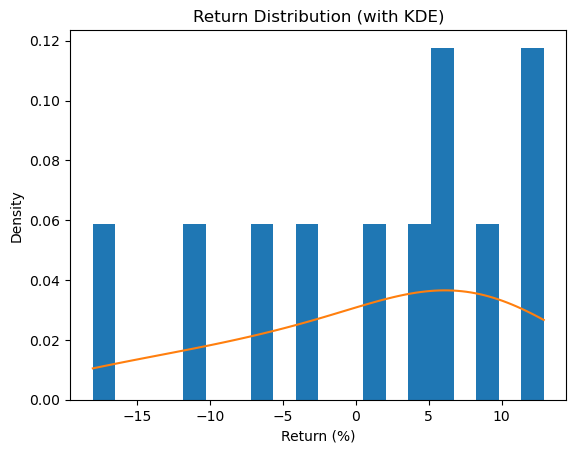

In [357]:
import numpy as np

plt.hist(list_of_returns, bins=20, density=True)

# KDE (smooth curve)
from scipy.stats import gaussian_kde

kde = gaussian_kde(list_of_returns)
x_vals = np.linspace(min(list_of_returns), max(list_of_returns), 100)

plt.plot(x_vals, kde(x_vals))
plt.xlabel("Return (%)")
plt.ylabel("Density")
plt.title("Return Distribution (with KDE)")
plt.show()

In [344]:
#Analyzing my results

#Note: This doesn't include yields received, which could add a significant amount of nearly risk-free P&L

In [ ]:
#Note to self

#Try to add in 
#     UST yields (rates shock vs risk shock)
#     DXY (USD strength crushes EM)
# And create a multifactor risk model

In [ ]:
#Also ask ChatGPT to
#turn this into a logistic model (probability of recovery) and help me make a multifactor predictor as opposed to a single factor model
#plug it directly into your backtest (only trade high-probability recoveries)

In [ ]:
#Split model into:

#high vol regime (VIX > 20/25)
#low vol regime

#Because recovery dynamics are fundamentally different.

In [ ]:
# =========================
# =========================

# 4. Even More Exploratory Data Analysis

# =========================
# =========================

In [ ]:
lags = range(0, 252)
best_lag = []
for lag in lags:
    corr = df['vix'].corr(df['emb_price'].shift(-lag))
    best_lag.append(corr)

print(min(best_lag))

In [ ]:
df[["em_return", "oil_return", "delta_vix", "delta_credit_spread"]].corr()

In [ ]:
#Here's a graph of Emerging Market Bonds Overlaid w/ VIX
import matplotlib.pyplot as plt

# Create a figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Filter data after 2020
#mask = df.index > "2020-01-01"

# Top subplot - Emerging Market Returns
ax1.plot(df.index, df["emb_price"], label="Emerging Market Price", color='blue')
ax1.set_ylabel("Price")
ax1.set_title("Emerging Market Price")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom subplot - VIX Fluctuations
ax2.plot(df.index, df["vix"], label="VIX", color='red')
ax2.set_xlabel("Date")
ax2.set_ylabel("VIX Value")
ax2.set_title("VIX Fluctuations")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Here's a graph of Emerging Market Bonds Overlaid w/ Oil
import matplotlib.pyplot as plt

# Create a figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Filter data after 2020
mask = df.index > "2020-01-01"

# Top subplot - Emerging Market Returns
ax1.plot(df.index[mask], df["emb_price"][mask], label="Emerging Market Price", color='blue')
ax1.set_ylabel("Price")
ax1.set_title("Emerging Market Price (After 2020)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom subplot - Oil Fluctuations
ax2.plot(df.index[mask], df["oil_price"][mask], label="Oil", color='red')
ax2.set_xlabel("Date")
ax2.set_ylabel("Price")
ax2.set_title("Oil (After 2020)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Here's a graph of Emerging Market Bonds Overlaid w/ Credit Spreads
import matplotlib.pyplot as plt

# Create a figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Filter data after 2020
mask = df.index > "2020-01-01"

# Top subplot - Emerging Market Returns
ax1.plot(df.index[mask], df["emb_price"][mask], label="Emerging Market Price", color='blue')
ax1.set_ylabel("Price")
ax1.set_title("Emerging Market Price (After 2020)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom subplot - Oil Fluctuations
ax2.plot(df.index[mask], df["credit_spread"][mask], label="Oil", color='red')
ax2.set_xlabel("Date")
ax2.set_ylabel("Spreads (%)")
ax2.set_title("Credit Spreads (After 2020)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#New model idea, test correlation between raw prices; also test within windows where like the VIX is well above it's rolling mean and see if you
#can predict prices a couple months from now to see if they go up

In [ ]:
#Use a tool to test for local minima and maxima

In [ ]:
#From what I see, and from Guru's results, VIX and credit spreads spike while EM bond prices severely dip at the same time. 
#After the VIX normalizes, EM bonds recorrect upwards. I think this is due to capital flight and lack of flight to safety mechanism
#But I think that there's no real risk with above Investment Grade EM Bonds like Mexico (Might have to do fundamental research)

In [ ]:
df[["emb_price", "oil_price", "vix", "credit_spread"]].corr()

In [ ]:
#Examining correlations in the window between the different factors during the year 2020, when the VIX spiked up significantly:
df_2020 = df['2020-01-01':'2021-01-01']
df_2020[["emb_price", "oil_price", "vix", "credit_spread"]].corr()

In [ ]:
#The factors are so much more highly correlated with emerging market bond prices when we restrict our window to a period of crisis when the VIX spikes up

In [ ]:
max_vix = max(df_2020["vix"])
print(max_vix)
max_position = df_2020["vix"].idxmax()
df_window_2020 = df_2020[df_2020.index > max_position]

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.set_xlabel("Date")
ax1.set_ylabel("Price")
ax1.set_title("Emerging Market Bond Index after 2020 VIX Spike")
plt.plot(df_window_2020.index, df_window_2020["emb_price"])

In [ ]:
df_window_2020

In [ ]:
df_window_2020_prices = df_window_2020[df_window_2020["emb_price"] >= 0.90 * max(df_window_2020["emb_price"])]
df_window_2020_prices

In [ ]:
df_2024 = df['2024-01-01':'2025-01-01']
df_2024[["emb_price", "oil_price", "vix", "credit_spread"]].corr()

In [ ]:
max_vix = max(df_2024["vix"])
print(max_vix)
max_position = df_2024["vix"].idxmax()
df_window_2024 = df_2024[df_2024.index > max_position]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

ax1.set_xlabel("Date")
ax1.set_ylabel("Price")
ax1.set_title("Emerging Market Bond Index after 2024 VIX Spike")
ax1.plot(df_window_2024.index, df_window_2024["emb_price"])

ax2.set_xlabel("Date")
ax2.set_ylabel("Price")
ax2.set_title("Emerging Market Bonds during 2024-2025")
ax2.plot(df_2024.index, df_2024["emb_price"])

ax3.set_xlabel("Date")
ax3.set_ylabel("VIX")
ax3.set_title("VIX during 2024")
ax3.plot(df_2024.index, df_2024["vix"])

In [ ]:
df_window_2024

In [ ]:
df_window_2024_prices = df_window_2024[df_window_2024["emb_price"] >= 0.95 * max(df_window_2024["emb_price"])]
df_window_2024_prices

In [ ]:
df_2025 = df['2025-01-01':'2026-01-01']
df_2025[["emb_price", "oil_price", "vix", "credit_spread"]].corr()

In [ ]:
max_vix = max(df_2025["vix"])
print(max_vix)
max_position = df_2025["vix"].idxmax()
df_window_2025 = df_2025[df_2025.index > max_position]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

ax1.set_xlabel("Date")
ax1.set_ylabel("Price")
ax1.set_title("Emerging Market Bond Index after 2025 VIX Spike")
ax1.plot(df_window_2025.index, df_window_2025["emb_price"])

ax2.set_xlabel("Date")
ax2.set_ylabel("Price")
ax2.set_title("Emerging Market Bonds during 2025-2026")
ax2.plot(df_2025.index, df_2025["emb_price"])

ax3.set_xlabel("Date")
ax3.set_ylabel("VIX")
ax3.set_title("VIX during 2025")
ax3.plot(df_2025.index, df_2025["vix"])

In [ ]:
df_window_2025

In [ ]:
df_window_2025_prices = df_window_2025[df_window_2025["emb_price"] >= 0.90 * max(df_window_2025["emb_price"])]
df_window_2025_prices

In [ ]:
#Analyzing the three periods where the VIX shot up the most in the 2020s: 2020, 2024, and 2025: 
#I see a pattern where the higher the VIX spike, the greater the increase in prices

In [ ]:
#Here are the selections of dates where the VIX is especially high

In [ ]:
#My analysis on Guru's strategy and modelling: Some problems I have are focusing exclusively on returns and not on raw prices, though obviously the correlations still will be the same. I also think the model doesn't account for lags and delays larger than just one day which weakens our correlation.

In [56]:
#2. Split index - determines the row number we go up to in order to ensure we get the 70-30 ratio for train-test split
#So we will split the data at row 1757
#That means the first 1757 rows are used for training, and the latter 754 rows used for testing
split = int(len(df) * 0.7)
print(split)

1758
